<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:30px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 128 · Solutions</div>
  <div style="font-size:30px;font-weight:900;line-height:1.1;margin:10px 0 6px">Forecasting Models &#183; Solutions</div>
  <div style="font-size:14px;color:#e0f2fe;max-width:740px;line-height:1.6">Five challenges, each verified in code.</div>

</div>

# Forecasting Models &#183; Challenge Solutions
Worked solutions to the five challenges from Chapter 128. Each uses the same airport-passenger series, the same chronological train/test split, and MAPE to compare forecasts.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing, Holt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings('ignore')
def mape(a,f): return float(np.mean(np.abs((a.values-np.asarray(f))/a.values))*100)
try: raw = pd.read_excel('../../data/forecasting-models--airport_passengers.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'forecasting-models--airport_passengers.xlsx', sheet_name='Data')
raw['month']=pd.to_datetime(raw['month']); s = raw.set_index('month')['passengers'].asfreq('MS')
train, test = s[:-12], s[-12:]; print('train', len(train), '| test', len(test))

train 108 | test 12


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 1</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Baselines</div>
<div style="color:#4a5578;margin-top:5px">Compute naive, seasonal-naive, and drift baselines; which is the bar to beat?</div>
</div>

In [3]:
naive  = np.repeat(train.iloc[-1], 12)
snaive = train.iloc[-12:].values
drift  = train.iloc[-1] + (np.arange(1,13))*((train.iloc[-1]-train.iloc[0])/(len(train)-1))
for name,f in [('naive',naive),('seasonal-naive',snaive),('drift',drift)]: print(f'{name:16s} MAPE {mape(test,f):.2f}%')

naive            MAPE 13.63%
seasonal-naive   MAPE 4.13%
drift            MAPE 15.15%


The **seasonal-naive** forecast (about 4.1%) is the one to beat here: it captures the yearly wave that the naive and drift baselines miss. Every serious model should clear it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 2</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">The exponential-smoothing ladder</div>
<div style="color:#4a5578;margin-top:5px">Fit SES, Holt (trend), and Holt-Winters (trend+season); see what each added component buys you.</div>
</div>

In [4]:
ses = SimpleExpSmoothing(train).fit()
holt = Holt(train).fit()
hw = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit()
for name,m in [('SES (level only)',ses),('Holt (+trend)',holt),('Holt-Winters (+season)',hw)]: print(f'{name:24s} MAPE {mape(test, m.forecast(12)):.2f}%')

SES (level only)         MAPE 13.63%
Holt (+trend)            MAPE 14.32%
Holt-Winters (+season)   MAPE 2.83%


Each rung adds a component. **SES** tracks only the level (flat forecast). **Holt** adds a trend but, still blind to the yearly wave, can even do slightly worse by extrapolating a bare trend. Only **Holt-Winters**, which adds seasonality, captures both forces and wins decisively. The lesson: add the component your data actually has.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 3</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Choosing SARIMA orders</div>
<div style="color:#4a5578;margin-top:5px">Fit two candidate orders and pick by AIC; forecast the winner with a 95% interval.</div>
</div>

In [5]:
cands = [((1,1,1),(1,1,1,12)), ((0,1,1),(0,1,1,12))]
fits = {(o,so): SARIMAX(train, order=o, seasonal_order=so, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False) for o,so in cands}
for k,m in fits.items(): print(f'SARIMA{k[0]}{k[1]}  AIC {m.aic:.0f}  MAPE {mape(test, m.forecast(12)):.2f}%')
best = min(fits.values(), key=lambda m: m.aic); fc = best.get_forecast(12); ci = fc.conf_int()
print('\nchosen by lowest AIC; 12-month forecast with 95% interval:')
print(pd.concat([fc.predicted_mean.round(0).rename('forecast'), ci.round(0)], axis=1).head(3))

SARIMA(1, 1, 1)(1, 1, 1, 12)  AIC 1436  MAPE 3.74%
SARIMA(0, 1, 1)(0, 1, 1, 12)  AIC 1440  MAPE 3.71%

chosen by lowest AIC; 12-month forecast with 95% interval:
            forecast  lower passengers  upper passengers
2023-01-01   44828.0           41163.0           48493.0
2023-02-01   44120.0           40243.0           47996.0
2023-03-01   51089.0           47182.0           54996.0


**AIC** balances fit against complexity, so it is a fair way to pick orders without touching the test set. The chosen model produces both a point forecast and a **95% prediction interval**, honest uncertainty that grows with the horizon.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 4</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Head to head</div>
<div style="color:#4a5578;margin-top:5px">Compare Holt-Winters and SARIMA on the same holdout.</div>
</div>

                  model  MAPE_%
     Holt-Winters (mul)    2.83
SARIMA(1,1,1)(1,1,1,12)    3.74


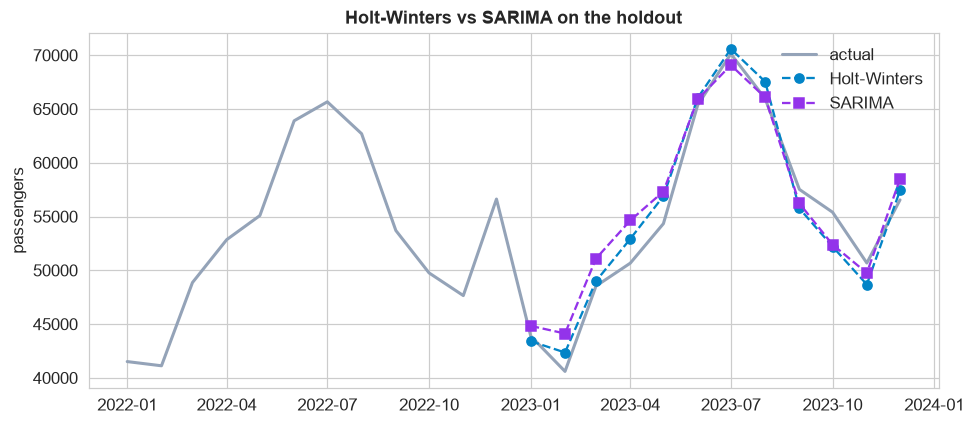

In [6]:
hw = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit()
sar = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
res = pd.DataFrame({'model':['Holt-Winters (mul)','SARIMA(1,1,1)(1,1,1,12)'], 'MAPE_%':[round(mape(test, hw.forecast(12)),2), round(mape(test, sar.forecast(12)),2)]})
print(res.to_string(index=False))
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(s.index[-24:], s.values[-24:], color=GREY, lw=2, label='actual')
ax.plot(test.index, hw.forecast(12), 'o--', color=EM, label='Holt-Winters'); ax.plot(test.index, sar.forecast(12), 's--', color=PUR, label='SARIMA')
ax.set(title='Holt-Winters vs SARIMA on the holdout', ylabel='passengers'); ax.legend(); plt.tight_layout(); plt.show()

Both clear the baseline; **Holt-Winters edges SARIMA** on this multiplicative series. There is no universal winner, the holdout decides, and it is cheap to fit both.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 5</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Static vs dynamic, and the horizon</div>
<div style="color:#4a5578;margin-top:5px">Show that multi-step (dynamic) error grows the further out you forecast.</div>
</div>

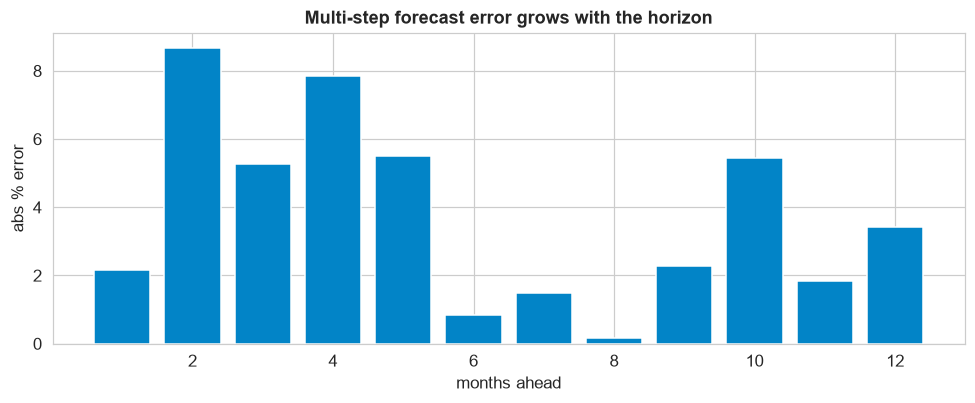

error at 1 month ahead: 2.2%  |  at 12 months ahead: 3.4%
a static one-step evaluation would hide this growth -> match the evaluation horizon to the decision


In [7]:
sar = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc = sar.forecast(12); errs = np.abs((test.values - fc.values)/test.values)*100
fig,ax=plt.subplots(figsize=(9,3.8)); ax.bar(range(1,13), errs, color=EM); ax.set(title='Multi-step forecast error grows with the horizon', xlabel='months ahead', ylabel='abs % error')
plt.tight_layout(); plt.show()
print('error at 1 month ahead: %.1f%%  |  at 12 months ahead: %.1f%%' % (errs[0], errs[-1]))
print('a static one-step evaluation would hide this growth -> match the evaluation horizon to the decision')

A **dynamic** forecast compounds its own errors as it rolls forward, so the further out you look, the wider the miss. Evaluating only **one step ahead** (static) hides that growth. Always test at the **horizon you will actually forecast**.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>